<a href="https://colab.research.google.com/github/pejmanrasti/traitement_des_signaux_M2-/blob/main/04_Liklihood_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The Likelihood Function

In statistics, the **likelihood function** is a fundamental concept in *likelihood estimation*, which is used to estimate the parameters of a statistical model. It quantifies how "likely" it is to observe a particular set of data given a specific set of model parameters.

**Key differences from Probability:**

*   **Probability Mass/Density Function (PMF/PDF):** For a given set of parameters, the PMF/PDF describes the probability of observing different outcomes (data).
    *   $P(X=x | \theta)$ - *Fixed parameters*, varying data.
*   **Likelihood Function:** For a fixed set of observed data, the likelihood function describes how probable different parameter values are.
    *   $L(\theta | x)$ - *Fixed data*, varying parameters.

Mathematically, for a given set of observed data $x = (x_1, x_2, ..., x_n)$ and a statistical model with parameters $\theta = (\theta_1, \theta_2, ..., \theta_k)$, the likelihood function $L(\theta | x)$ is numerically equal to the joint probability density (or mass) function of the observed data, but viewed as a function of the parameters $\theta$ for fixed data $x$.

If the observations are independent and identically distributed (i.i.d.), the likelihood function is the product of the individual probability density (or mass) functions:

$L(\theta | x_1, ..., x_n) = \prod_{i=1}^{n} f(x_i | \theta)$

Often, it's more convenient to work with the **log-likelihood function**, which is the natural logarithm of the likelihood function. This converts the product into a sum, simplifying calculations, especially for optimization problems:

$\ln L(\theta | x_1, ..., x_n) = \sum_{i=1}^{n} \ln f(x_i | \theta)$

### Example 1: Bernoulli Distribution

The Bernoulli distribution models the probability of success (1) or failure (0) in a single trial. It has one parameter, $p$, which is the probability of success.

**PMF:** $f(x | p) = p^x (1-p)^{1-x}$ for $x \in \{0, 1\}$

Suppose we observe $n$ i.i.d. Bernoulli trials, and we get $k$ successes and $n-k$ failures. The likelihood function is:

$L(p | x_1, ..., x_n) = \prod_{i=1}^{n} p^{x_i} (1-p)^{1-x_i} = p^{\sum x_i} (1-p)^{\sum (1-x_i)} = p^k (1-p)^{n-k}$

Let's plot this for a fixed dataset.

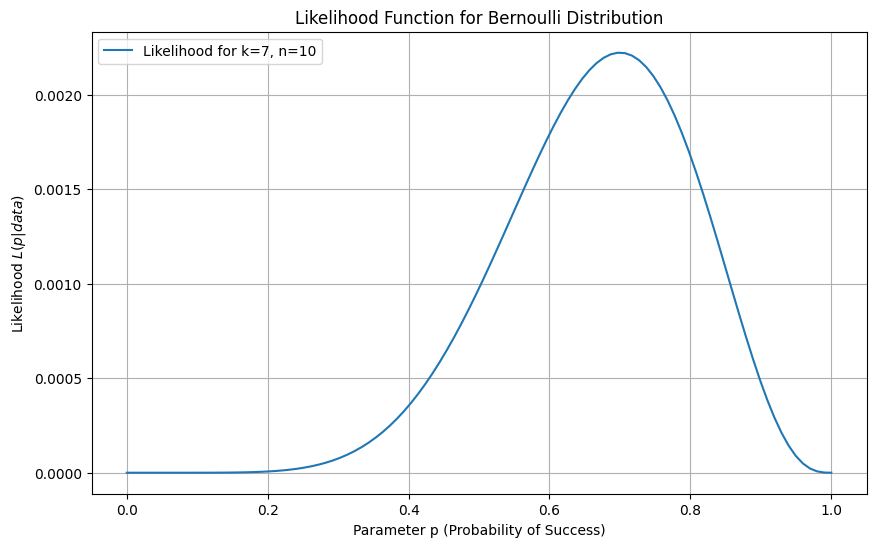

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Observed data: 7 successes out of 10 trials
data_bernoulli = [1, 1, 0, 1, 1, 0, 1, 1, 0, 1] # Example: 7 successes, 3 failures
k = sum(data_bernoulli) # Number of successes
n = len(data_bernoulli) # Total trials

# Define the likelihood function for Bernoulli
def likelihood_bernoulli(p, k, n):
    if not (0 <= p <= 1):
        return 0
    return (p**k) * ((1 - p)**(n - k))

# Create a range of possible 'p' values
p_values = np.linspace(0, 1, 100)

# Calculate likelihood for each 'p' value
likelihood_values = [likelihood_bernoulli(p, k, n) for p in p_values]

# Plot the likelihood function
plt.figure(figsize=(10, 6))
plt.plot(p_values, likelihood_values, label=f'Likelihood for k={k}, n={n}')
plt.xlabel('Parameter p (Probability of Success)')
plt.ylabel('Likelihood $L(p | data)$')
plt.title('Likelihood Function for Bernoulli Distribution')
plt.grid(True)
plt.legend()
plt.show()

### Example 2: Normal Distribution

The Normal (Gaussian) distribution is characterized by two parameters: the mean ($\mu$) and the standard deviation ($\sigma$).

**PDF:** $f(x | \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$

If we have $n$ i.i.d. observations $x_1, ..., x_n$, the likelihood function is:

$L(\mu, \sigma | x_1, ..., x_n) = \prod_{i=1}^{n} \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$

$= \left(\frac{1}{\sigma \sqrt{2\pi}}\right)^n \exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2\right)$

For simplicity, let's assume $\sigma$ is known and plot the likelihood function with respect to $\mu$.

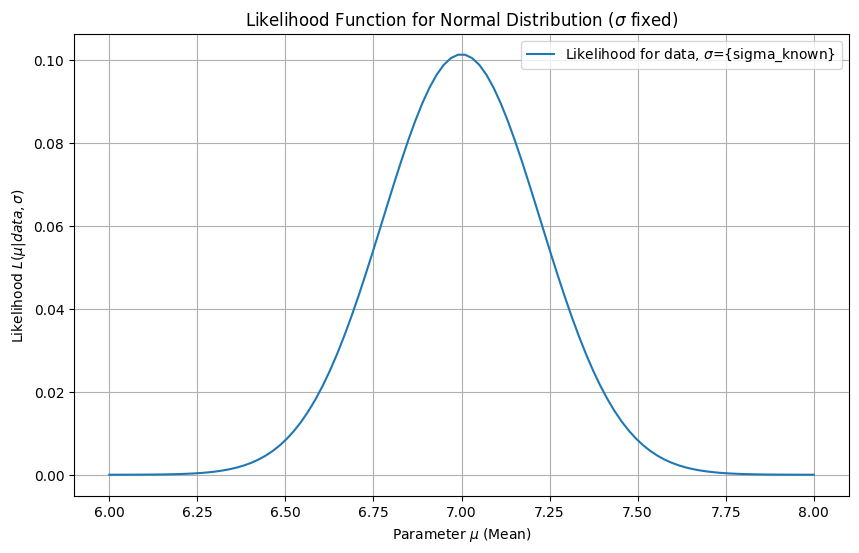

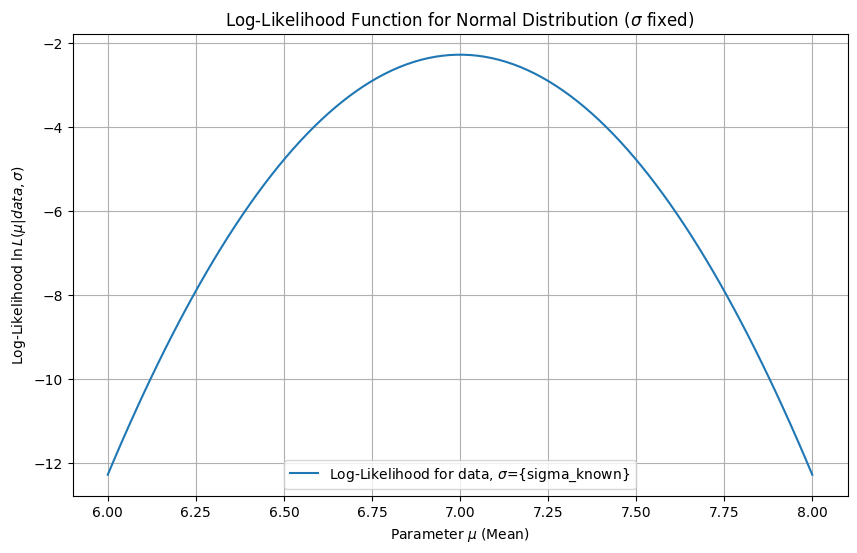

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Observed data (e.g., sample measurements)
data_normal = np.array([6.5, 7.0, 7.2, 6.8, 7.5])

# Assume known standard deviation
sigma_known = 0.5

# Define the likelihood function for Normal distribution (fixed sigma)
def likelihood_normal_fixed_sigma(mu, data, sigma):
    # The product of PDFs for each data point
    return np.prod(norm.pdf(data, loc=mu, scale=sigma))

# Create a range of possible 'mu' values around the sample mean
mu_values = np.linspace(np.mean(data_normal) - 1, np.mean(data_normal) + 1, 100)

# Calculate likelihood for each 'mu' value
likelihood_values_normal = [likelihood_normal_fixed_sigma(mu, data_normal, sigma_known) for mu in mu_values]

# Plot the likelihood function
plt.figure(figsize=(10, 6))
plt.plot(mu_values, likelihood_values_normal, label=r'Likelihood for data, $\sigma$={sigma_known}')
plt.xlabel(r'Parameter $\mu$ (Mean)')
plt.ylabel(r'Likelihood $L(\mu | data, \sigma)$')
plt.title(r'Likelihood Function for Normal Distribution ($\sigma$ fixed)')
plt.grid(True)
plt.legend()
plt.show()

# Log-likelihood function
def log_likelihood_normal_fixed_sigma(mu, data, sigma):
    return np.sum(norm.logpdf(data, loc=mu, scale=sigma))

log_likelihood_values_normal = [log_likelihood_normal_fixed_sigma(mu, data_normal, sigma_known) for mu in mu_values]

plt.figure(figsize=(10, 6))
plt.plot(mu_values, log_likelihood_values_normal, label=r'Log-Likelihood for data, $\sigma$={sigma_known}')
plt.xlabel(r'Parameter $\mu$ (Mean)')
plt.ylabel(r'Log-Likelihood $\ln L(\mu | data, \sigma)$')
plt.title(r'Log-Likelihood Function for Normal Distribution ($\sigma$ fixed)')
plt.grid(True)
plt.legend()
plt.show()

## Exercises for Students

---

### Exercise 1: Poisson Likelihood Function

The Poisson distribution is often used to model the number of events occurring in a fixed interval of time or space. It has one parameter, $\lambda$ (lambda), which represents the average rate of events.

**PMF:** $f(x | \lambda) = \frac{\lambda^x e^{-\lambda}}{x!}$ for $x \in \{0, 1, 2, ...\}$

**Problem:** Suppose you observe the number of cars passing a certain point on a road in 5 separate one-minute intervals: `[2, 5, 3, 4, 1]`. Assume these observations are i.i.d. from a Poisson distribution.

1.  **Write a Python function** to calculate the likelihood $L(\lambda | x)$ for a given $\lambda$ and the observed data.
2.  **Plot the likelihood function** for $\lambda$ values ranging from 0.1 to 10.0.
3.  **Identify the $\lambda$ value** that maximizes the likelihood function from your plot (this is the Maximum Likelihood Estimate, MLE).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Observed data
data_poisson = np.array([2, 5, 3, 4, 1])

# TODO: Define the likelihood function for Poisson distribution
def likelihood_poisson(lambda_param, data):
    # Hint: Use np.prod() and poisson.pmf()
    pass # Your code here

# TODO: Create a range of possible 'lambda' values
lambda_values = np.linspace(0.1, 10.0, 100)

# TODO: Calculate likelihood for each 'lambda' value
# likelihood_values_poisson = [...]

# TODO: Plot the likelihood function
# plt.figure(figsize=(10, 6))
# plt.plot(lambda_values, likelihood_values_poisson, label='Likelihood for Poisson data')
# plt.xlabel('Parameter $\lambda$ (Average Rate)')
# plt.ylabel('Likelihood $L(\lambda | data)$')
# plt.title('Likelihood Function for Poisson Distribution')
# plt.grid(True)
# plt.legend()
# plt.show()

# TODO: Find the lambda that maximizes the likelihood
# mle_lambda = lambda_values[np.argmax(likelihood_values_poisson)]
# print(f"Maximum Likelihood Estimate (MLE) for \u03BB: {mle_lambda:.2f}")

### Exercise 2: Comparing Likelihoods

**Problem:** You are given a set of temperature measurements (in Celsius) for a chemical reaction: `[22.1, 22.5, 21.9, 22.3, 22.0, 22.4]`.

You want to determine if this data is more likely to have come from a Normal distribution with:

*   **Scenario A:** Mean $\mu_A = 22.0$ and Standard Deviation $\sigma_A = 0.2$
*   **Scenario B:** Mean $\mu_B = 22.5$ and Standard Deviation $\sigma_B = 0.5$

**Task:**

1.  **Calculate the log-likelihood** of the observed data under Scenario A.
2.  **Calculate the log-likelihood** of the observed data under Scenario B.
3.  **Which scenario is more likely** given the observed data? Explain your reasoning based on the log-likelihood values.

In [4]:
import numpy as np
from scipy.stats import norm

# Observed temperature data
temperature_data = np.array([22.1, 22.5, 21.9, 22.3, 22.0, 22.4])

# Scenario A parameters
mu_A = 22.0
sigma_A = 0.2

# Scenario B parameters
mu_B = 22.5
sigma_B = 0.5

# TODO: Calculate the log-likelihood for Scenario A
# log_likelihood_A = ...
# print(f"Log-Likelihood for Scenario A: {log_likelihood_A:.4f}")

# TODO: Calculate the log-likelihood for Scenario B
# log_likelihood_B = ...
# print(f"Log-Likelihood for Scenario B: {log_likelihood_B:.4f}")

# TODO: Determine which scenario is more likely and explain why
# if ...:
#    print("Scenario A is more likely.")
# else:
#    print("Scenario B is more likely.")